In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Input
import statsmodels.api as sm
from linearmodels.iv import IV2SLS
import seaborn as sns
from itertools import product

2025-05-08 14:13:38.763287: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df = pd.read_csv('/Users/colin/Library/CloudStorage/OneDrive-UniversitedeMontreal/On_Going_Studies/IVADO_Project/car_prices.csv')
df['saleid'] = df.index

### Check and Process the selling date

In [5]:
df['origin_saledate'] = df['saledate']

# Step 1: Clean the string (remove the part in parentheses)
df['saledate'] = df['saledate'].str.replace(r'\s*\(.*?\)', '', regex=True).str.strip()

# Step 2: Convert to datetime (handles GMT offsets) - invalid dates will become NaT
df['saledate'] = pd.to_datetime(df['saledate'], utc=True, errors='coerce')

# Step 3: check for failed parses
invalid_rows = df[df['saledate'].isna()]
print('Nber of rows with invalid dates:', invalid_rows.shape[0])

Nber of rows with invalid dates: 38


In [6]:
# Remove the very few cases with invalid selling dates (its also drops rows with invalid states)
df = df[~df['saledate'].isna()]

In [7]:
df['saledate'].map(lambda x: (x.year, x.month)).value_counts() #Too few sales 2014, Jan, Feb; and 2015, Apr, Jul (I shhould drop them)

saledate
(2015, 2)     163052
(2015, 1)     140611
(2015, 6)      99938
(2014, 12)     53518
(2015, 5)      52444
(2015, 3)      46277
(2015, 4)       1450
(2015, 7)       1302
(2014, 1)        206
(2014, 2)          1
Name: count, dtype: int64

In [8]:
pd.crosstab(df['state'], df['saledate'].map(lambda x: f"({x.year}, {x.month})"))
#I can define markets by (year, month, state) and drop markets with a total sales of less than 20

saledate,"(2014, 1)","(2014, 12)","(2014, 2)","(2015, 1)","(2015, 2)","(2015, 3)","(2015, 4)","(2015, 5)","(2015, 6)","(2015, 7)"
state,,,,,,,,,,
ab,0,70,0,192,299,55,2,155,151,4
al,0,0,0,0,20,6,0,0,0,0
az,0,1398,0,1995,2256,575,21,1114,1375,6
ca,24,10626,0,19884,21101,4618,134,6790,9784,187
co,3,839,0,18,3198,845,13,732,2113,14
fl,21,6823,1,18620,24697,8588,169,7103,16703,220
ga,30,2449,0,9112,10188,3269,58,3865,5700,79
hi,0,107,0,439,301,108,2,50,227,3
il,4,2407,0,5435,6677,2018,92,2369,4440,36


### Define markets by (year of selling, month of selling, state)- the product will be set later by the variable 'make'

In [10]:
#Define markets by (year, month, state) and drop markets with a total sales of less than 20

df['market'] = df['saledate'].map(lambda x: f"{x.year}_{x.month}_") + df['state'].astype('str')
markets_tab = df['market'].value_counts()
selected_markets = markets_tab.iloc[np.where(markets_tab>=20)].index
df = df[df['market'].isin(selected_markets)]
idmarket_mask = dict([(i, selected_markets[i]) for i in range(len(selected_markets))])
marketid_mask = dict([(selected_markets[i], i) for i in range(len(selected_markets))])
df['marketid'] = df['market'].map(marketid_mask)

### Check missings in potential relevant characteristics

In [12]:
df['color'] = df['color'].replace({'—':np.nan})
df['interior'] = df['interior'].replace({'—':np.nan})

In [13]:
#Check missing values

print('Nber of rows that have missing values for <<make>>:', sum(df['make'].isna())) #Need to impute those
print('Nber of rows, with non missing <<make>>, that have missing values for <<model>>:', sum(df[~df['make'].isna()]['model'].isna()))
print('Nber of rows with missing values for <<trim>>:', sum(df[~df['make'].isna()]['trim'].isna()))
print('Nber of rows that have missing values for <<transmission>>:', sum(df['transmission'].isna())) #Need to impute those
print('Nber of rows that have missing values for <<state>>:', sum(df['state'].isna()))
print('Nber of rows that have missing values for <<condition>>:', sum(df['condition'].isna()))
print('Nber of rows that have missing values for <<odometer>>:', sum(df['odometer'].isna()))
print('Nber of rows that have missing values for <<color>>:', sum(df['color'].isna())) 
print('Nber of rows that have missing values for <<interior>>:', sum(df['interior'].isna()))
print('Nber of rows that have missing values for <<seller>>:', sum(df['seller'].isna()))
print('Nber of rows that have missing values for <<mmr>>:', sum(df['mmr'].isna()))
print('Nber of rows that have missing values for <<sellingprice>>:', sum(df['sellingprice'].isna()))

Nber of rows that have missing values for <<make>>: 10282
Nber of rows, with non missing <<make>>, that have missing values for <<model>>: 98
Nber of rows with missing values for <<trim>>: 350
Nber of rows that have missing values for <<transmission>>: 65269
Nber of rows that have missing values for <<state>>: 0
Nber of rows that have missing values for <<condition>>: 11794
Nber of rows that have missing values for <<odometer>>: 93
Nber of rows that have missing values for <<color>>: 25416
Nber of rows that have missing values for <<interior>>: 17808
Nber of rows that have missing values for <<seller>>: 0
Nber of rows that have missing values for <<mmr>>: 0
Nber of rows that have missing values for <<sellingprice>>: 0


### Prepare data to be imputed in R (using multiple imputation chained equation - MICE)

The idea is to run an R code here. It was computationnally too heavy though. So I just dropped the missing values for the relevant attributes (see the next block of codes). The codes in this block are kept though; since they'll be usefull for the part of the workshop that adresses missing value imputation

In [15]:
CompleteNumericalVars = ['mmr','sellingprice']
CompleteUnorderedVars = ['year','state']
IncompleteNumericalVars = ['odometer']
IncompleteOrderedVars = ['condition']
IncompleteUnorderedVars = ['make','model','trim','body','transmission','color','interior']

In [16]:
df_to_impute = df[['saleid']+CompleteUnorderedVars+IncompleteUnorderedVars+IncompleteOrderedVars+IncompleteNumericalVars+CompleteNumericalVars]


In [17]:
#Set types that can be convenient when importing in R for missing imputation

for var in CompleteNumericalVars+IncompleteNumericalVars:
    df_to_impute.loc[:,var] = df_to_impute.loc[:,var].astype(np.float64).replace({np.nan:pd.NA})
for var in IncompleteOrderedVars:
    df_to_impute.loc[:,var] = df_to_impute.loc[:,var].astype(str).replace({'nan':pd.NA})
for var in CompleteUnorderedVars+IncompleteUnorderedVars:
    df_to_impute.loc[:,var] = df_to_impute.loc[:,var].astype(str).replace({'nan':pd.NA})


/var/folders/9z/sz2ngxdj74jgjqq9lbnltxmm0000gn/T/ipykernel_45866/3283340663.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[16639.0 9393.0 1331.0 ... 50561.0 16658.0 15008.0]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_to_impute.loc[:,var] = df_to_impute.loc[:,var].astype(np.float64).replace({np.nan:pd.NA})
/var/folders/9z/sz2ngxdj74jgjqq9lbnltxmm0000gn/T/ipykernel_45866/3283340663.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['5.0' '5.0' '45.0' ... '48.0' '38.0' '34.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_to_impute.loc[:,var] = df_to_impute.loc[:,var].astype(str).replace({'nan':pd.NA})
/var/folders/9z/sz2ngxdj74jgjqq9lbnltxmm0000gn/T/ipykernel_45866/3283340663.py:8: FutureWarning: Setting an item of incompatible dtype is de

In [18]:
df_to_impute.to_csv('df_to_impute.csv', index=False)

In [19]:
%load_ext rpy2.ipython

In [20]:

Hide_This_R_code= """
%%R -i df_to_impute -i CompleteNumericalVars -i CompleteUnorderedVars -i IncompleteNumericalVars -i IncompleteOrderedVars -i IncompleteUnorderedVars -o imputed_df

df <- df_to_impute

df <- as.data.frame(df)

library(readr)
library(mice)
library(dplyr)
library(parallel)
library(doParallel)

for (var in colnames(df)){
  if (var %in% IncompleteOrderedVars){
    df[,var] <- factor(as.integer(df[,var]), ordered=TRUE)
  }
  if (var %in% c(CompleteUnorderedVars, IncompleteUnorderedVars)){
    df[,var] <- factor(df[,var], ordered=FALSE)
  }
}

#The dataset is too heavy. For now, focus on incomlete rows, plus few additional rows (if incomplete rows are less than 50K).
incompleteness_filter <- !complete.cases(df)
complete_df <- df[!incompleteness_filter,]
nb_incomplete_rows <- sum(incompleteness_filter)
if (nb_incomplete_rows<=50000){
  sampled_rows <- sample_n(complete_df, 50000-nb_incomplete_rows)
  sampled_rows_filter <- df$saleid %in% sampled_rows$saleid
  final_filter <- incompleteness_filter | sampled_rows_filter
} else {
  final_filter <- incompleteness_filter
}

library(parallel)
library(doParallel)
nbcores <- detectCores() - 1


imputer <- parlmice(
  data=df[final_filter,-1],
  blocks=list(IncompleteOrderedVars, IncompleteUnorderedVars, IncompleteNumericalVars), 
  method=c('polr','polyreg','pmm'), #I would've used random forests ('rf','rf','rf') if there was not computation issue
  m=2, maxit=3, #default m=5, default maxit=5
  seed = 123, print = FALSE,
  cluster.seed = 123, n.core = nbcores, n.imp.core = 1
)


imputed_df <- complete(imputer)
str(head(imputed_df))

imputed_df <- cbind(df[final_filter,'saleid'], imputed_df)
imputed_df <- rbind(imputed_df,df[!final_filter,])
"""


Here is the final dataset. We still need to extract aggregate features at (market, product)-level. This is done in further cells

In [22]:
#Final df
df = df[['marketid','state','mmr','sellingprice','odometer','year','make','body','condition','color','interior']]
df = df.dropna()

In [23]:
df['state'].unique()

array(['ca', 'tx', 'pa', 'mn', 'az', 'wi', 'tn', 'md', 'fl', 'ne', 'oh',
       'mi', 'nj', 'ga', 'va', 'sc', 'in', 'il', 'co', 'ut', 'mo', 'nv',
       'ma', 'pr', 'nc', 'ny', 'or', 'wa', 'la', 'hi', 'qc', 'ab', 'on',
       'ok', 'ms', 'nm', 'al', 'ns'], dtype=object)

In [24]:
df.head()

,marketid,state,mmr,sellingprice,odometer,year,make,body,condition,color,interior
0,9,ca,20500.0,21500.0,16639.0,2015,Kia,SUV,5.0,white,black
1,9,ca,20800.0,21500.0,9393.0,2015,Kia,SUV,5.0,white,beige
2,2,ca,31900.0,30000.0,1331.0,2014,BMW,Sedan,45.0,gray,black
3,2,ca,27500.0,27750.0,14282.0,2015,Volvo,Sedan,41.0,white,black
4,9,ca,66000.0,67000.0,2641.0,2014,BMW,Sedan,43.0,gray,black


### Process the relevant attributes (manufacturing year, make [i.e. the brand], body, [exterior] color, interior [color])
The idea is to reduce the number of categories per categorical variable by regrouping less frequent categories into the 'other' labels.

In [26]:
df['year'] = df['year'].map(lambda x: x if x>=2000 else 1999)
df['make'] = df['make'].map(lambda x: str(x).lower())
df['body'] = df['body'].map(lambda x: str(x).lower())


In [27]:
make_mask = {
    'gmc truck':'gmc', 'dodge tk':'dodge', 'mazda tk':'mazda', 'hyundai tk':'hyundai', 'mercedes-b':'mercedes-benz',
    'chev truck':'chevrolet', 'ford tk':'ford', 'ford truck':'ford', 'vw':'volkswagen'
}
df['make'] = df['make'].replace(make_mask)
make_table = df['make'].value_counts()
popular_makes = set(make_table[make_table>=10000].index)-{''}
df['make'] = df['make'].map(lambda x: x if x in popular_makes else 'other_make')

In [28]:
body_categories_mask = body_type_map = {
    #suvs
    'suv': 'suv',      
    #sedans
    'sedan': 'sedan', 'g sedan': 'sedan', 'elantra coupe': 'sedan',
    #coupes
    'coupe': 'coupe', 'g coupe': 'coupe', 'genesis coupe': 'coupe', 'cts coupe': 'coupe', 'koup': 'coupe', 'cts-v coupe': 'coupe',
    'g37 coupe': 'coupe', 'q60 coupe': 'coupe',
    # convertibles
    'convertible': 'convertible', 'g convertible': 'convertible', 'g37 convertible': 'convertible', 'q60 convertible': 'convertible',
    'beetle convertible': 'convertible', 'granturismo convertible': 'convertible',
    # wagons
    'wagon': 'wagon', 'cts wagon': 'wagon', 'tsx sport wagon': 'wagon', 'cts-v wagon': 'wagon',
    # hatchbacks
    'hatchback': 'hatchback',
    # vans / minivans
    'minivan': 'van', 'van': 'van', 'e-series van': 'van', 'promaster cargo van': 'van', 'ram van': 'van', 'transit van': 'van',
    # pickup trucks - cab variants
    'crew cab': 'pickup', 'double cab': 'pickup', 'crewmax cab': 'pickup', 'access cab': 'pickup', 'king cab': 'pickup',
    'supercrew': 'pickup', 'extended cab': 'pickup', 'supercab': 'pickup', 'regular cab': 'pickup', 'regular-cab': 'pickup',
    'quad cab': 'pickup', 'club cab': 'pickup', 'xtracab': 'pickup', 'mega cab': 'pickup', 'cab plus': 'pickup', 'cab plus 4': 'pickup'
}
df['body'] = df['body'].map(body_categories_mask)

In [ ]:
color_table = df['color'].value_counts()
popular_colors = set(color_table[color_table>=10000].index)-{''}
df['color'] = df['color'].map(lambda x: x if x in popular_colors else 'other_color')

interior_table = df['interior'].value_counts()
popular_interiors = set(interior_table[interior_table>=10000].index)-{''}
df['interior'] = df['interior'].map(lambda x: x if x in popular_interiors else 'other_interior')


### Aggregate data at (market,product)-level: compute the market sales (called logshare so far) and the averages of attributes (including the price)

In [ ]:
ContinuousVars = ['mmr','sellingprice','odometer','condition']
CategoricalVars = ['year','body','color','interior']
Categories = [(var, cat) for var in CategoricalVars for cat in df[var].value_counts().index[1:]] #The most frequent category excluded for each variable
productid = 'make'
df1 = df.groupby(by=['marketid',productid]).apply(lambda x: x.assign(**dict(
    [('logshare',x.shape[0])]+
    [(var,x[var].mean()) for var in ContinuousVars] + 
    [(var+'_'+str(cat),x[x[var]==cat].shape[0]/x.shape[0]) for var,cat in Categories]
)), include_groups=True).reset_index(drop=True)[['marketid',productid,'state','logshare']+ContinuousVars+[var+'_'+str(cat) for var,cat in Categories]].drop_duplicates()

print(df1.shape)


/var/folders/9z/sz2ngxdj74jgjqq9lbnltxmm0000gn/T/ipykernel_45866/1060426424.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df1 = df.groupby(by=['marketid',productid]).apply(lambda x: x.assign(**dict(


(3518, 43)


### Import the 2015  state-varying population data (used as market size), merge with current data and complete the computation of log-market shares (relative to the outise good 'oo')

In [33]:
pop_df = pd.read_csv('/Users/colin/Library/CloudStorage/OneDrive-UniversitedeMontreal/On_Going_Studies/IVADO_Project/states_populations_yr2015.csv')
pop_df['population (2015)'] = pop_df['population (2015)'].map(lambda x: x.replace(',','')).astype('float')
outsideoption_df = df1[['marketid','state']].groupby(by=['marketid']).apply(lambda x: x.assign(totalsales=x.shape[0])).reset_index(drop=True).drop_duplicates()
pop_df = pop_df.merge(outsideoption_df,on='state')
pop_df['logshare_oo'] = np.log(1-pop_df['totalsales']/pop_df['population (2015)'])
df1 = pop_df.merge(df1, on=['state','marketid'])
df1['logshare'] = np.log(df1['logshare']/df1['population (2015)'])-df1['logshare_oo']

print(pop_df.shape, outsideoption_df.shape, df1.shape)

(239, 6) (239, 3) (3518, 47)


/var/folders/9z/sz2ngxdj74jgjqq9lbnltxmm0000gn/T/ipykernel_45866/3430731411.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outsideoption_df = df1[['marketid','state']].groupby(by=['marketid']).apply(lambda x: x.assign(totalsales=x.shape[0])).reset_index(drop=True).drop_duplicates()


In [34]:
df1 #.iloc[:,10:]

,state,"state, full name",population (2015),marketid,totalsales,logshare_oo,make,logshare,mmr,sellingprice,...,color_silver,color_blue,color_red,color_other_color,color_gold,color_green,interior_gray,interior_beige,interior_tan,interior_other_interior
0,ca,California (US),39144818.0,1,16,-4.087387e-07,bmw,-10.252215,20767.215786,20901.973208,...,0.106445,0.085445,0.018103,0.012310,0.006517,0.010862,0.167994,0.118030,0.060101,0.041999
1,ca,California (US),39144818.0,1,16,-4.087387e-07,chevrolet,-10.006306,11392.341450,11546.932616,...,0.170442,0.077576,0.068516,0.045300,0.036806,0.013590,0.377690,0.087769,0.026048,0.020385
2,ca,California (US),39144818.0,1,16,-4.087387e-07,chrysler,-11.469063,9048.655257,8861.980440,...,0.198044,0.095355,0.063570,0.031785,0.031785,0.022005,0.374083,0.061125,0.012225,0.017115
3,ca,California (US),39144818.0,1,16,-4.087387e-07,dodge,-10.783278,10291.748768,10424.014778,...,0.168719,0.094828,0.118227,0.038177,0.027094,0.008621,0.316502,0.067734,0.016010,0.014778
4,ca,California (US),39144818.0,1,16,-4.087387e-07,ford,-9.579921,12735.397412,12776.851017,...,0.144547,0.076525,0.089834,0.024399,0.015527,0.027357,0.341959,0.149353,0.058410,0.019224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3513,ns,Nova Scotia (Canada),943000.0,217,6,-6.362693e-06,dodge,-12.370521,6912.500000,4825.000000,...,0.000000,0.250000,0.000000,0.250000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000
3514,ns,Nova Scotia (Canada),943000.0,217,6,-6.362693e-06,ford,-12.370521,7400.000000,6400.000000,...,0.000000,0.500000,0.000000,0.250000,0.000000,0.000000,0.750000,0.250000,0.000000,0.000000
3515,ns,Nova Scotia (Canada),943000.0,217,6,-6.362693e-06,hyundai,-11.271909,8181.250000,8216.666667,...,0.166667,0.083333,0.416667,0.083333,0.000000,0.000000,0.500000,0.166667,0.000000,0.083333
3516,ns,Nova Scotia (Canada),943000.0,217,6,-6.362693e-06,nissan,-13.063668,8725.000000,8900.000000,...,0.000000,0.000000,0.500000,0.500000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000


### Some distribuutions

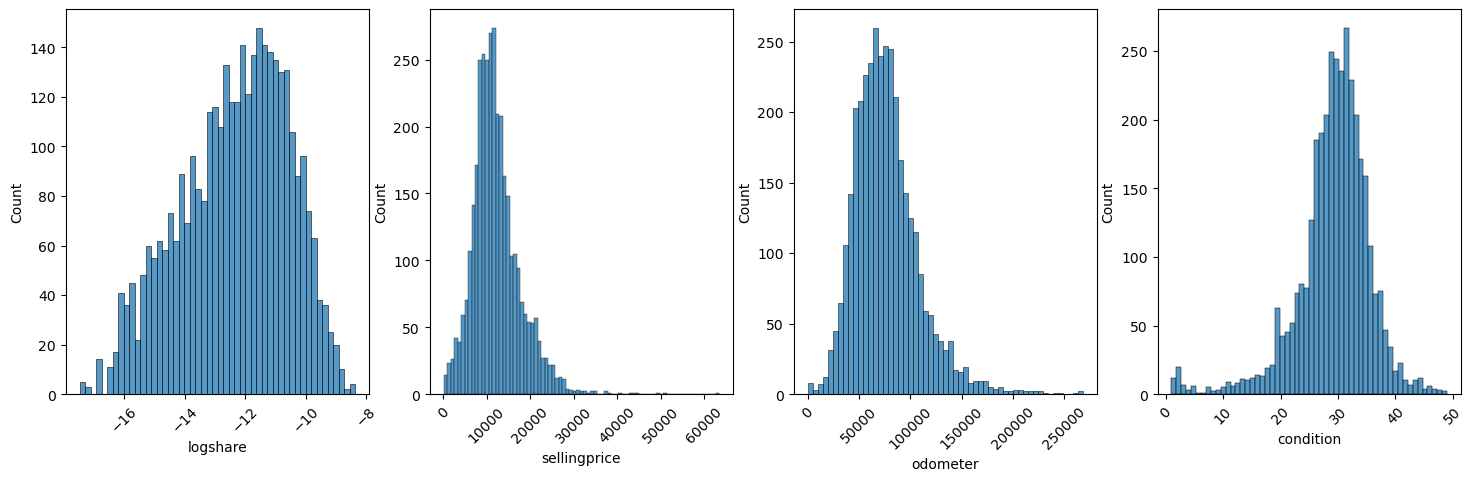

In [36]:
plt.figure(figsize=(18,5))
ax=plt.subplot(1,4,1); ax.tick_params(axis='x', labelrotation=45)
sns.histplot(df1['logshare'], bins=50); ax.tick_params(axis='x', labelrotation=45)
ax=plt.subplot(1,4,2); ax.tick_params(axis='x', labelrotation=45)
sns.histplot(df1['sellingprice'])
ax=plt.subplot(1,4,3); ax.tick_params(axis='x', labelrotation=45)
sns.histplot(df1['odometer'])
ax=plt.subplot(1,4,4); ax.tick_params(axis='x', labelrotation=45)
sns.histplot(df1['condition']); ax.tick_params(axis='x', labelrotation=45)

plt.xticks(rotation=45) # Rotate x-axis labels
#plt.tight_layout() # Adjust layout to avoid label cutoff
plt.show()


### Simple exercise shows that at first sight demand and price seems to have positive relation, at least for the less priced cars

In [38]:
##Price | sales linear correlation
df1[['logshare','sellingprice']].corr()

,logshare,sellingprice
logshare,1.000000,0.137767
sellingprice,0.137767,1.000000


In [39]:
### Neural Network (predict sales with price only)

X = (df1[['sellingprice']] - df1[['sellingprice']].mean())/df1[['sellingprice']].std()
Y = (df1[['logshare']] - df1[['logshare']].mean())/df1[['logshare']].std()

nnmodel = keras.Sequential([
    Input(shape=(X.shape[1],)),
    layers.Dense(64, activation='relu'),
    #layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    #layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    #layers.Dropout(0.5),
    layers.Dense(1)  # Single output neuron for regression
])

nnmodel.compile(optimizer='adam',
              loss='mae',               # Mean Squared Error for regression
              metrics=['mse']         # Mean Absolute Error for evaluation
             )

print(nnmodel.summary())

nnmodel.fit(X, Y, epochs=50, batch_size=32, validation_split=0.2, verbose=False)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,513 (33.25 KB)

 Trainable params: 8,513 (33.25 KB)

 Non-trainable params: 0 (0.00 B)

None


110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


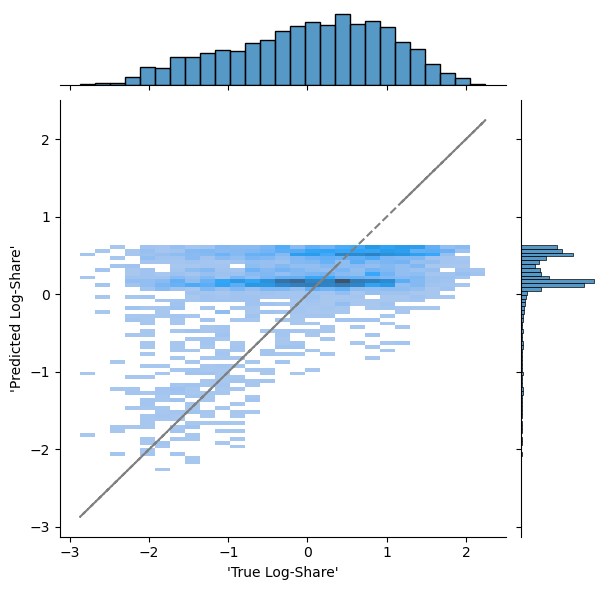

In [40]:
##Predictions from Neural Network

ax = sns.jointplot(x=Y.iloc[:,0],y=nnmodel.predict(X)[:,0], kind="hist")
plt.plot(Y.iloc[:,0], Y.iloc[:,0], linestyle='--', color='gray')
ax.set_axis_labels(xlabel="'True Log-Share'", ylabel="'Predicted Log-Share'")

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


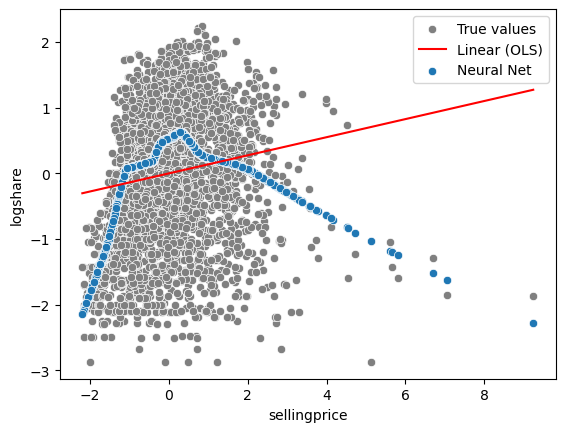

In [41]:
#sns.scatterplot(x=df1['sellingprice'], y=Y.iloc[:,0], linestyle='--', color='gray')
X1 = sm.add_constant(X)
ols_coefs = np.linalg.inv(X1.T@X1)@X1.T@Y

sns.scatterplot(x=X.iloc[:,0], y=Y.iloc[:,0], color='gray', label='True values')
sns.lineplot(x=X.iloc[:,0], y=(X1@np.array(ols_coefs)).iloc[:,0], color='red', label='Linear (OLS)')
sns.scatterplot(x=X.iloc[:,0],y=nnmodel.predict(X)[:,0], label='Deep NN')
plt.legend()
plt.show()

### Extract instruments (for price) as the sum of characteristics of rival products in the same market (see S Berry, J Levinsohn, A Pakes, 1995)

In [43]:
### Set data for multivariate regressions

exog_df = df1.iloc[:,np.array([3]+list(np.arange(10,df1.shape[1])))]

Z = exog_df.groupby(['marketid']).apply(
    lambda x: x.assign(**dict(
        [('Nb_CompetingProducts',x.shape[0]-1)]+[(var+'_CompetingProducts', x[var].sum()-x[var]) for var in exog_df.columns[1:]]+\
        []#[(var1+'*'+var2+'_CompetingProducts', (x[var1]*x[var2]).sum()-x[var1]*x[var2]) for var1, var2 in list(product(list(exog_df.columns[1:]), repeat=2))]
    )), include_groups=False
).reset_index(drop=True).drop(exog_df.iloc[:,1:].columns, axis=1)


In [44]:
Z.describe(percentiles=np.arange(0,11)/10)

,Nb_CompetingProducts,odometer_CompetingProducts,condition_CompetingProducts,year_2013_CompetingProducts,year_2014_CompetingProducts,year_2011_CompetingProducts,year_2008_CompetingProducts,year_2007_CompetingProducts,year_2010_CompetingProducts,year_2006_CompetingProducts,...,color_silver_CompetingProducts,color_blue_CompetingProducts,color_red_CompetingProducts,color_other_color_CompetingProducts,color_gold_CompetingProducts,color_green_CompetingProducts,interior_gray_CompetingProducts,interior_beige_CompetingProducts,interior_tan_CompetingProducts,interior_other_interior_CompetingProducts
count,3518.000000,3.518000e+03,3518.000000,3518.000000,3518.000000,3518.000000,3518.000000,3518.000000,3518.000000,3518.000000,...,3518.000000,3518.000000,3518.000000,3518.000000,3518.000000,3518.000000,3518.000000,3518.000000,3518.000000,3518.000000
mean,14.182490,1.075476e+06,417.100172,2.319393,1.726837,1.171236,1.008316,1.006254,0.791534,0.873133,...,2.436851,1.431255,1.033078,0.920267,0.272830,0.303117,4.765740,1.407071,1.331479,0.338310
std,1.932383,2.854045e+05,82.016195,1.058782,0.937586,0.566980,0.448454,0.470627,0.403676,0.463526,...,0.671378,0.476354,0.374092,0.455752,0.191800,0.237743,1.135813,0.774526,0.840552,0.211868
min,2.000000,2.909300e+04,38.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0%,2.000000,2.909300e+04,38.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10%,11.000000,7.654985e+05,320.851680,0.818371,0.523372,0.536443,0.436111,0.465649,0.366667,0.325708,...,1.579923,0.833333,0.506068,0.458333,0.000000,0.058298,3.396539,0.166667,0.166667,0.082230
20%,14.000000,8.493879e+05,376.405962,1.310997,0.883056,0.776365,0.690873,0.660856,0.554182,0.537521,...,2.055229,1.090968,0.800446,0.627922,0.100743,0.125000,3.983333,0.679362,0.627955,0.151670
30%,15.000000,9.239669e+05,401.487035,1.756099,1.145061,0.896913,0.780054,0.759277,0.636529,0.640951,...,2.222291,1.259384,0.932104,0.728032,0.169401,0.188758,4.284836,0.909218,0.860020,0.225042
40%,15.000000,9.995092e+05,422.100998,2.113770,1.419464,1.010679,0.866928,0.877927,0.694402,0.746421,...,2.335899,1.350086,1.005743,0.801630,0.204021,0.234429,4.533656,1.166013,1.059441,0.284707
50%,15.000000,1.049021e+06,437.447198,2.364281,1.722399,1.120676,0.969415,0.970962,0.756519,0.833333,...,2.439054,1.441874,1.069641,0.878919,0.250000,0.265714,4.733591,1.535434,1.281519,0.342129


In [45]:
def reduce_to_full_rank(A, tol=1e-10):
    """Return a full-rank version of matrix A by removing linearly dependent columns."""
    #A must be a 2D-array
    Q, R = np.linalg.qr(A)
    independent = np.abs(np.diag(R)) > tol
    return A[:, independent]

def get_non_collinear_instruments(Z, X_exog = None, tol=1e-10):
    # Regress each instrument on the exogenous variables
    # Keep instruments that are not perfectly explained by exogenous variables

    if np.all(X_exog==None):
        X = np.ones((Z.shape[0], 1)) # other exogenous reduce to constant only
    else:
        X = np.asarray(X_exog)
        X = np.hstack([X, np.ones((X.shape[0], 1))])  # add constant

    keep = []
    NewZ = Z
    for col in Z.columns:
        y = Z[col].values
        Xcol0 = np.hstack([NewZ.drop([col],axis=1), X])  # add other instruments
        Xcol = reduce_to_full_rank(Xcol0)
        beta = np.linalg.lstsq(Xcol, y, rcond=None)[0]
        y_hat = Xcol @ beta
        residual = y - y_hat    
        if np.linalg.norm(residual) > tol:
            keep.append(col)
        else:
            NewZ = NewZ.drop([col],axis=1)

    return Z[keep], keep

### Exclude instruments that could cause collinearity issues and define the names for the dependant variable, the endogenous (price) and exogenous covariates, and the instruments. Define the final data.

In [47]:
dep_var = ['logshare']
endog_vars = ['sellingprice']
exog_vars = list(exog_df.columns)[1:]
Z, instr_vars = get_non_collinear_instruments(Z, df1[exog_vars])
data = sm.add_constant(df1.join(Z)[['logshare']+exog_vars+endog_vars+instr_vars])
exog_vars = ['const'] + exog_vars


In [56]:
df.to_csv('processed_car_prices.csv')
df1.to_csv('aggregate_car_prices.csv')
data.to_csv('finaldata_car_prices.csv')

### Run OLS regression

In [58]:
### Multivariate OLS regressions : then plot (price, predicted share) when non-price covariates are at their means

olsmodel = sm.OLS(data[dep_var], data[exog_vars + endog_vars]).fit()
print(olsmodel.summary())

                            OLS Regression Results                            
Dep. Variable:               logshare   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     16.60
Date:                Thu, 08 May 2025   Prob (F-statistic):           1.13e-98
Time:                        14:22:53   Log-Likelihood:                -6732.7
No. Observations:                3518   AIC:                         1.354e+04
Df Residuals:                    3479   BIC:                         1.378e+04
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

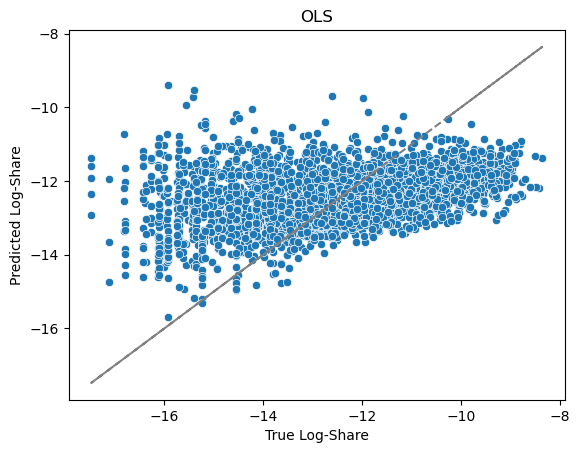

In [60]:
##Prediction from OLS

sns.scatterplot(x=data[dep_var].iloc[:,0],y=olsmodel.predict(data[exog_vars + endog_vars]))
plt.plot(data[dep_var].iloc[:,0], data[dep_var].iloc[:,0], linestyle='--', color='gray')
plt.xlabel("True Log-Share"); plt.ylabel("Predicted Log-Share")
plt.title('OLS')
plt.show()

### Run IV2SLS (with prices being linear function of instruments and included exogenous)

In [69]:
##IV2SLS

iv2slsmodel = IV2SLS(dependent=data[dep_var], exog=data[exog_vars], endog=data[endog_vars], instruments=data[instr_vars]).fit()

print(iv2slsmodel.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:               logshare   R-squared:                      0.1447
Estimator:                    IV-2SLS   Adj. R-squared:                 0.1353
No. Observations:                3518   F-statistic:                    524.55
Date:                Thu, May 08 2025   P-value (F-stat)                0.0000
Time:                        14:24:00   Distribution:                 chi2(38)
Cov. Estimator:                robust                                         
                                                                              
                                    Parameter Estimates                                    
                         Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------------
const                      -11.556     1.3598    -8.4983     0.0000     -14.221     -8.8906


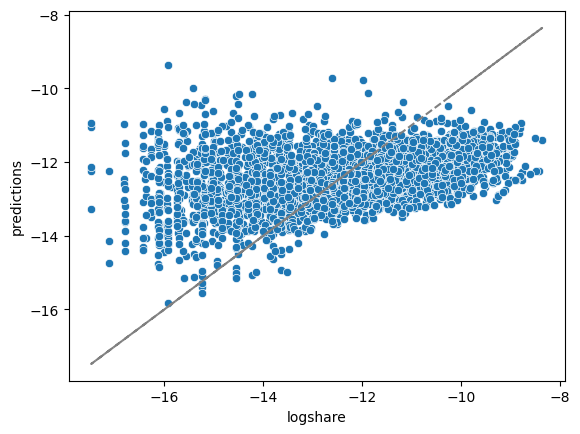

In [71]:
##Prediction from IV2SLS
sns.scatterplot(x=data[dep_var].iloc[:,0],y=iv2slsmodel.predict(exog=data[exog_vars],endog=data[endog_vars]).iloc[:,0])
plt.plot(data[dep_var], data[dep_var], linestyle='--', color='gray')

In [75]:
##Check the IV2SLS result manually 
X = np.array(data[exog_vars+endog_vars])
Y = np.array(data[['logshare']])
Z1 = np.array(data[exog_vars+instr_vars])
Pz = Z1@np.linalg.inv(Z1.T@Z1)@Z1.T

Xhat = Pz@X
Beta_IV = pd.DataFrame(np.linalg.inv(Xhat.T@Xhat)@Xhat.T@Y, index=exog_vars+endog_vars)
Beta_IV

,0
const,-11.555749
odometer,-0.000009
condition,0.042765
year_2013,-0.468047
year_2014,-0.489251
year_2011,-1.310671
year_2008,-1.826966
year_2007,-2.112969
year_2010,-1.745504
year_2006,-1.553062


### Run Neural Network

In [227]:
##Deep Neural Network

X = data[exog_vars[1:]+endog_vars]; Y = data[dep_var]
#X = (X-X.mean())/X.std(); Y = (Y-Y.mean())/Y.std()


nnmodel = keras.Sequential([
    Input(shape=(X.shape[1],)),
    layers.Dense(128, activation='relu'),
    #layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    #layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    #layers.Dropout(0.5),
    layers.Dense(1)  # Single output neuron for regression
])

nnmodel.compile(optimizer='adam',
              loss='mae',               # Mean Squared Error for regression (is more robust to outliers)
              metrics=['mse']         # Mean Absolute Error for evaluation
             )

print(nnmodel.summary())

nnmodel.fit(X, Y, epochs=50, batch_size=32, validation_split=0.2, verbose=False)



Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 128)            │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,145 (149.00 KB)

 Trainable params: 38,145 (149.00 KB)

 Non-trainable params: 0 (0.00 B)

None


110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


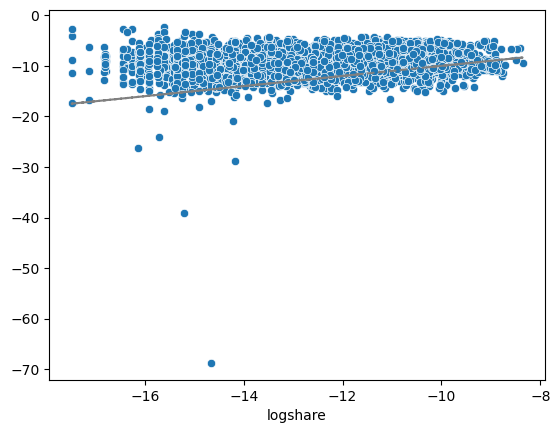

In [228]:
##Predictions from Neural Network

sns.scatterplot(x=Y.iloc[:,0],y=nnmodel.predict(X)[:,0])
plt.plot(Y.iloc[:,0], Y.iloc[:,0], linestyle='--', color='gray')

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


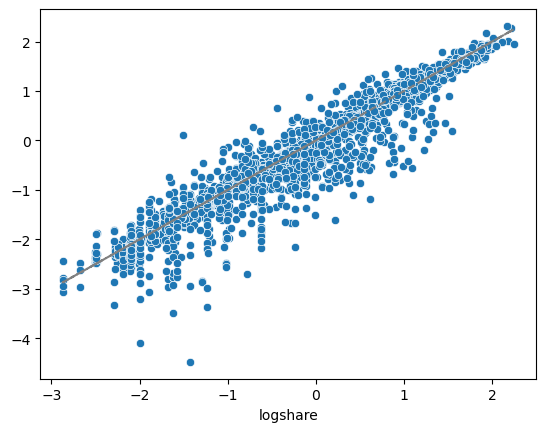

In [225]:
##Predictions from Neural Network

sns.scatterplot(x=Y.iloc[:,0],y=nnmodel.predict(X)[:,0])
plt.plot(Y.iloc[:,0], Y.iloc[:,0], linestyle='--', color='gray')

### Plot predicted (price, logshare) relation by the different methods

In [154]:
data_at_means = data.copy()
means = data_at_means[exog_vars+instr_vars].mean(axis=0)
data_at_means[exog_vars+instr_vars] = data_at_means[exog_vars+instr_vars].apply(lambda x: means, axis=1)


110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


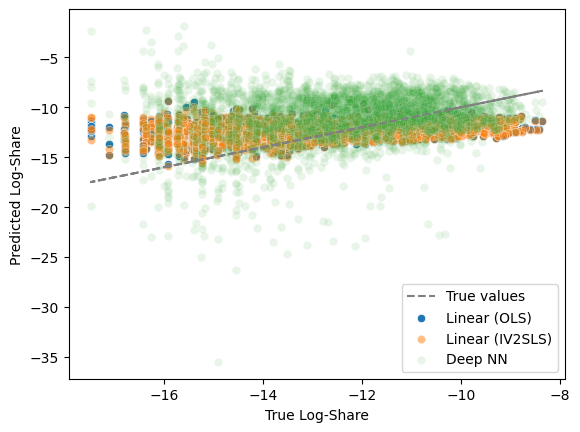

In [168]:
X = data[exog_vars+endog_vars]; Y = data[dep_var]
plt.plot(data[dep_var].iloc[:,0], data[dep_var].iloc[:,0], linestyle='--', color='gray', label='True values') #True
sns.scatterplot(x=data[dep_var].iloc[:,0],y=olsmodel.predict(data[exog_vars + endog_vars]), alpha=1, label='Linear (OLS)') #OLS-predicted
sns.scatterplot(x=data[dep_var].iloc[:,0],y=iv2slsmodel.predict(exog=data[exog_vars],endog=data[endog_vars]).iloc[:,0], alpha=0.5, label='Linear (IV2SLS)') #IV2SLS-predicted
sns.scatterplot(x=Y.iloc[:,0],y=nnmodel.predict(X)[:,0], alpha=0.1, label='Deep NN')
plt.xlabel("True Log-Share"); plt.ylabel("Predicted Log-Share")
plt.title('Predictions')
plt.legend()
plt.show()

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


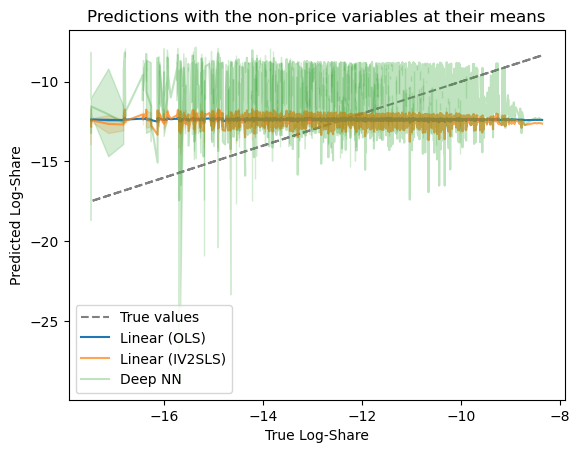

In [190]:
X = data_at_means[exog_vars[1:]+endog_vars]; Y = data_at_means[dep_var]
plt.plot(data_at_means[dep_var].iloc[:,0], data_at_means[dep_var].iloc[:,0], linestyle='--', color='gray', label='True values') #True
sns.lineplot(x=data_at_means[dep_var].iloc[:,0],y=olsmodel.predict(data_at_means[exog_vars + endog_vars]), alpha=1, label='Linear (OLS)') #OLS-predicted
sns.lineplot(x=data_at_means[dep_var].iloc[:,0],y=iv2slsmodel.predict(exog=data_at_means[exog_vars],endog=data_at_means[endog_vars]).iloc[:,0], alpha=0.7, label='Linear (IV2SLS)') #IV2SLS-predicted
sns.lineplot(x=Y.iloc[:,0],y=nnmodel.predict(X)[:,0], alpha=0.3, label='Deep NN')
plt.xlabel("True Log-Share"); plt.ylabel("Predicted Log-Share")
plt.title('Predictions with the non-price variables at their means')
plt.legend()
plt.show()

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


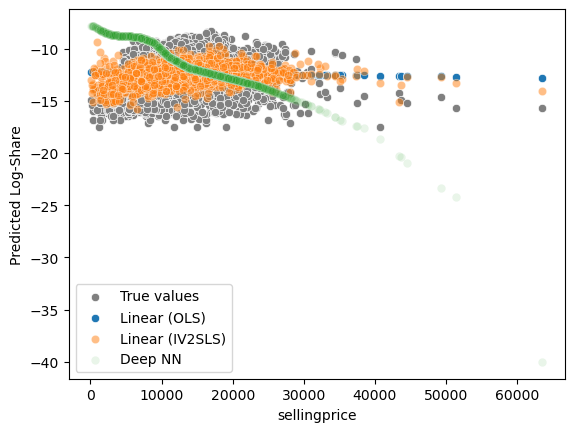

In [194]:
X = data_at_means[exog_vars+endog_vars]; Y = data_at_means[dep_var]
sns.scatterplot(x=data_at_means[endog_vars].iloc[:,0], y=data_at_means[dep_var].iloc[:,0], color='gray', label='True values') #True
sns.scatterplot(x=data_at_means[endog_vars].iloc[:,0],y=olsmodel.predict(data_at_means[exog_vars + endog_vars]), alpha=1, label='Linear (OLS)') #OLS-predicted
sns.scatterplot(x=data_at_means[endog_vars].iloc[:,0],y=iv2slsmodel.predict(exog=data[exog_vars],endog=data_at_means[endog_vars]).iloc[:,0], alpha=0.5, label='Linear (IV2SLS)') #IV2SLS-predicted
sns.scatterplot(x=data_at_means[endog_vars].iloc[:,0],y=nnmodel.predict(X)[:,0], alpha=0.1, label='Deep NN')
plt.xlabel(endog_vars[0]); plt.ylabel("Predicted Log-Share")
plt.legend()
plt.show()

,const,odometer,condition,year_2013,year_2014,year_2011,year_2008,year_2007,year_2010,year_2006,...,color_blue,color_red,color_other_color,color_gold,color_green,interior_gray,interior_beige,interior_tan,interior_other_interior,sellingprice
0,NaN,0.0,-0.002898,0.0,0.001362,0.0,0.007751,0.002004,0.0,0.003076,...,0.0,0.025637,-0.005405,0.0,-0.021502,-0.002976,0.0,0.0,0.0,1.557357
1,NaN,0.0,-0.002898,0.0,0.001362,0.0,0.007751,0.002004,0.0,0.003076,...,0.0,0.025637,-0.005405,0.0,-0.021502,-0.002976,0.0,0.0,0.0,-0.130729
2,NaN,0.0,-0.002898,0.0,0.001362,0.0,0.007751,0.002004,0.0,0.003076,...,0.0,0.025637,-0.005405,0.0,-0.021502,-0.002976,0.0,0.0,0.0,-0.615220
3,NaN,0.0,-0.002898,0.0,0.001362,0.0,0.007751,0.002004,0.0,0.003076,...,0.0,0.025637,-0.005405,0.0,-0.021502,-0.002976,0.0,0.0,0.0,-0.333356
4,NaN,0.0,-0.002898,0.0,0.001362,0.0,0.007751,0.002004,0.0,0.003076,...,0.0,0.025637,-0.005405,0.0,-0.021502,-0.002976,0.0,0.0,0.0,0.091205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3513,NaN,0.0,-0.002898,0.0,0.001362,0.0,0.007751,0.002004,0.0,0.003076,...,0.0,0.025637,-0.005405,0.0,-0.021502,-0.002976,0.0,0.0,0.0,-1.343680
3514,NaN,0.0,-0.002898,0.0,0.001362,0.0,0.007751,0.002004,0.0,0.003076,...,0.0,0.025637,-0.005405,0.0,-0.021502,-0.002976,0.0,0.0,0.0,-1.059476
3515,NaN,0.0,-0.002898,0.0,0.001362,0.0,0.007751,0.002004,0.0,0.003076,...,0.0,0.025637,-0.005405,0.0,-0.021502,-0.002976,0.0,0.0,0.0,-0.731665
3516,NaN,0.0,-0.002898,0.0,0.001362,0.0,0.007751,0.002004,0.0,0.003076,...,0.0,0.025637,-0.005405,0.0,-0.021502,-0.002976,0.0,0.0,0.0,-0.608360
